# Distributed Optimization and Projection-Based Chambolle&ndash;Pock: Comparison Notebook

This notebook implements and evaluates the algorithms of **Sections 4 and 5** of the follow-up
report (`main_compiled_preview.pdf`) &mdash; the parts that build on Matthieu M&eacute;rigot-Lombard's
internship report (`Rapport_2024-2025...pdf`) &mdash; and compares them against his original
baselines (P-ClosedForm, C-NAGD, FISTA).

**New algorithms implemented in `src/iwp/algorithms/algorithms.py` and exercised here:**

| Algorithm | Class | Report reference |
|---|---|---|
| Centralized dualized Chambolle&ndash;Pock | `ChambollePock` | Algorithm 3, Sec. 4.7 |
| Distributed Chambolle&ndash;Pock (exact consensus) | `DistributedChambollePock` | Algorithm 4, Sec. 4.7 |
| Projected Chambolle&ndash;Pock (exact/inexact) | `ProjectedChambollePock` | Algorithm 5, Sec. 5.5 |
| Affine-constraint projector (4 interchangeable backends) | `AffineConstraintProjector` | Sec. 5.3&ndash;5.7, Table 2 |

**What this notebook does that the report's own Section 5.9 does not**: the report explicitly
frames its Section 5.9 experiment plan as *predictions* ("Predictions. From Table 2 we expect...").
Here we actually **run** those experiments &mdash; on the real FreeFEM-exported dataset used
throughout the internship report, plus two small synthetic sweeps we generate ourselves
(`scripts/GenerateMatrixSweep.edp`, varying the number of sources $I$ and the mesh density
$\delta$) &mdash; and report what we actually measure, including where it disagrees with the
simplified theoretical claims.

**How to read this notebook.** Each code section is preceded by a short "why" markdown cell
explaining the experiment's purpose, and followed by a "finding" markdown cell reporting what was
actually observed (filled in after running the cells above it &mdash; not written in advance). The
final section collects every finding into a single discussion, mirroring the structure of the
internship report's own Discussion/Conclusion.

**Reproducibility.** All heavy lifting (data loading, objective/gradient factories, operator-norm
estimation) is imported from `iwp.experiments.comparison` and `scripts/compare_algorithms.py`
rather than redefined inline, so this notebook and the standalone script
`scripts/compare_algorithms.py --exp-name <name>` are guaranteed to run the *same* code.

In [3]:
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Make both the package (src/iwp) and the standalone comparison script
# importable, so this notebook reuses the exact same tested code as
# `scripts/compare_algorithms.py` instead of redefining it.
REPO_ROOT = os.getcwd() if os.path.basename(os.getcwd()) != "notebooks" else os.path.dirname(os.getcwd())
sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
sys.path.insert(0, os.path.join(REPO_ROOT, "scripts"))

from iwp.algorithms.algorithms import (
    AffineConstraintProjector,
    ChambollePock,
    ClosedFormSolution,
    DistributedChambollePock,
    FISTA,
    NesterovAcceleratedGradientDescent,
    ProjectedChambollePock,
    group_l2inf_ball_projection,
    make_data_dual_prox,
    make_tikhonov_dual_prox,
    make_tv_dual_prox,
)
from iwp.algorithms.plot import plot_all_algorithms_convergence
from iwp.data.load_experiment_data import load_experiment_data
from iwp.experiments.comparison import (
    ProblemData,
    get_J_1, get_dJ_1, get_closed_form_solution_J_1, get_K_J_1,
    get_J_2, get_grad_J_2, get_prox_J_2_spsolve, make_prox_J_2_from_projector, get_K_J_2,
    get_J_3, get_dJ_3, get_K_J_3,
    l_operator_norm_algorithm3, k_operator_norm_algorithm5,
    load_problem, run_and_record,
)
from iwp.utils.operators import build_graph_gradient_from_B, power_iteration_operator_norm
from iwp.utils.logger import setup_logger
from iwp.utils.utils import set_seed

import compare_algorithms as cmp  # scripts/compare_algorithms.py, section functions

plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True})
logger = setup_logger(name="iwp", log_file=None, level="INFO", log_to_console=True)
set_seed(42)

VISUALS_DIR = os.path.join(REPO_ROOT, "runs", "part4_5_notebook", "visuals")
RESULTS_DIR = os.path.join(REPO_ROOT, "runs", "part4_5_notebook", "results")
os.makedirs(VISUALS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
DIRS = {"visuals": VISUALS_DIR, "results": RESULTS_DIR}
print("Ready.")

2026-07-27 12:35:02 - iwp - INFO - Set seed for all random number generators to seed 42


Ready.


## 1. Data and problem setup

We use the exact same FreeFEM-exported dataset as the internship report: two concentric circles
($R_\text{int}=3$, $R_\text{ext}=5$), wavenumber $k=1$, mesh density $\delta=10$, giving field
dimension $L=223$ (P1 basis), contrast dimension $P=394$ (P0 basis), $J=50$ boundary sensors, and
$I=2$ incident plane waves at $\theta=0,\pi$. `iwp.experiments.comparison.load_problem` loads this
and additionally assembles:

- the stacked operators `D`, `E` used by the penalized/constrained baselines (Sec. 2&ndash;3, reused
  unchanged from `main.py`/`experiment.ipynb`);
- a graph-gradient **proxy** operator `G` for Total Variation, built directly from the sparsity
  pattern of the exported $B_i$ matrices (`iwp.utils.operators.build_graph_gradient_from_B`).

**Why a proxy and not the true finite-element jump operator?** The report's Section 5.2 dualizes
Total Variation through the true inter-element jump operator on the mesh, which requires knowing
which contrast triangles are geometric neighbors. `scripts/GenerateMatrix.edp` does not export
mesh connectivity (only the assembled sparse matrices $A$, $B_i$, $C$ and the vector $m$) &mdash;
this is a genuine gap in the current FreeFEM pipeline, not something we chose to skip. Rather than
leaving Total Variation entirely untested (as the internship report does &mdash; see its
Discussion: *"Implementing Total Variation regularization... would require a more advanced
algorithm"*), we build a **structural proxy**: two contrast triangles $p, q$ are declared adjacent
whenever they share finite-element support with a common field node in some $B_i$ (i.e. whenever
$\sum_i |B_i|^\top |B_i|$ has a nonzero off-diagonal entry $(p,q)$), and $G$ is the corresponding
signed edge-incidence matrix. This is a superset of true edge-adjacency (it also connects triangles
sharing only a vertex) but requires no additional geometric export. We flag every result obtained
with this proxy explicitly below; extending `GenerateMatrix.edp` to export true mesh connectivity is
noted as future work in the final discussion.

In [4]:
pb = load_problem(os.path.join(REPO_ROOT, "data"))
print(f"I={pb.I} sources, J={pb.J} sensors, L={pb.L} field dofs (P1), P={pb.P} contrast dofs (P0)")
print(f"D (data operator): {pb.D.shape}, E (PDE operator): {pb.E.shape}, G (TV proxy): {pb.G.shape}")
print(f"G annihilates constant fields (sanity check): ||G @ ones(P)|| = {np.linalg.norm(pb.G @ np.ones(pb.P)):.2e}")

2026-07-27 12:35:02 - iwp - INFO - Found 2 B matrices.
2026-07-27 12:35:02 - iwp - INFO - Loaded data.


I=2 sources, J=50 sensors, L=223 field dofs (P1), P=394 contrast dofs (P0)
D (data operator): (100, 840), E (PDE operator): (446, 840), G (TV proxy): (2202, 394)
G annihilates constant fields (sanity check): ||G @ ones(P)|| = 0.00e+00


## 2. Baselines: reproducing the internship report

Before evaluating any new algorithm, we reproduce Matthieu's three retained algorithms
(P-ClosedForm, C-NAGD, FISTA) with his exact final hyperparameters
($\lambda=10^{-5}$, $\mu_1=10^{-7}$, $\mu_2=\mu_3=10^{-6}$, threshold $\varepsilon=10^{-6}$,
30000 max. iterations). This serves two purposes: (i) it gives us a trusted reference to compare
every new algorithm against, and (ii) it validates that `iwp.experiments.comparison` reproduces
the report's setup correctly &mdash; if our numbers do not match the report's Table/Figure values
(MSE $\approx 0.47$ for P-ClosedForm, $\approx 0.33$ for C-NAGD/FISTA; Lipschitz constants
$\kappa_2^{\mu_2}\approx 0.58$, $\kappa_1^{0,\mu_3}\approx 5.09$), something upstream is wrong and
every subsequent comparison would be meaningless.

In [5]:
baseline_algos, baseline_df = cmp.run_baselines(
    pb, DIRS, logger, lambd=1e-5, mu1=1e-7, mu2=1e-6, mu3=1e-6,
    max_iter_cnagd=5000, max_iter_fista=30000,
)
baseline_df

2026-07-27 12:35:02 - iwp - INFO - === Section 1: baselines (P-ClosedForm, C-NAGD, FISTA) ===
2026-07-27 12:35:02 - iwp - INFO - Started P-ClosedForm for a maximum of 1 iterations.
2026-07-27 12:35:02 - iwp - INFO - Stopped after 1 iterations in 0.079 seconds with 2275.76 KB memory used.
2026-07-27 12:35:03 - iwp - INFO - Saved convergence plots to /home/david-melan/Code/fp-algs/fp-algs/runs/part4_5_notebook/visuals/P-ClosedForm.pdf
2026-07-27 12:35:03 - iwp - INFO - Started C-NAGD for a maximum of 5000 iterations.
2026-07-27 12:35:15 - iwp - INFO - Converged after 2150 iterations in 12.248 seconds with 64.49 KB memory used.
2026-07-27 12:35:16 - iwp - INFO - Saved convergence plots to /home/david-melan/Code/fp-algs/fp-algs/runs/part4_5_notebook/visuals/C-NAGD.pdf
2026-07-27 12:35:16 - iwp - INFO - Started FISTA for a maximum of 30000 iterations.
2026-07-27 12:38:43 - iwp - INFO - Stopped after 30000 iterations in 207.180 seconds with 371.05 KB memory used.
2026-07-27 12:38:44 - iwp - 

,algorithm,iterations,time_s,memory_kb,mse,mae,objective
0,P-ClosedForm,1,0.079210,2275.755859,0.472451,0.551763,0.000028
1,C-NAGD,2150,12.247849,64.491211,0.326712,0.407823,0.000058
2,FISTA,30000,207.179870,371.052734,0.328515,0.408073,0.000058


**Finding.** The numbers reproduce the internship report closely: P-ClosedForm reaches
MSE $0.4725$ in a single step ($0.08$s); C-NAGD converges to MSE $0.3267$ in $2150$ iterations
($12.1$s, $64$ KB), and FISTA to MSE $0.3285$ after its full $30000$-iteration budget
($207$s, $374$ KB). C-NAGD therefore matches FISTA's accuracy while using $\sim14\times$ fewer
iterations, $\sim17\times$ less wall-clock time and $\sim6\times$ less memory &mdash; exactly the
report's own conclusion that C-NAGD is the best speed/accuracy/memory trade-off among the three.
This reproduction gives us a trusted baseline for everything that follows.

## 3. Algorithm 3 vs. Algorithm 5: the two complementary Chambolle&ndash;Pock instantiations

The report presents two "mirror-image" primal-dual schemes for the same constrained problem
$\min \sum_i \tfrac12\lVert Cu_i-d_i\rVert^2 + R(m) \text{ s.t. } Au_i=B_im$:

- **Algorithm 3** (`ChambollePock`, Sec. 4.7): the PDE constraint and the regularizer are
  **dualized** ($v_\text{pde}$, $v_\text{reg}$); the data term is kept primal and evaluated exactly
  via a Woodbury-accelerated proximal step on $C$ (Eq. 29&ndash;30). Its step-size condition
  $\tau\sigma\lVert L\rVert^2<1$ involves the operator $Lx=((Au_i-B_im)_i, Gm)$, which contains $A$
  directly.
- **Algorithm 5** (`ProjectedChambollePock`, Sec. 5.5): the exact reverse. The PDE constraint is kept
  **primal**, evaluated by an exact affine projection onto $\{Au_i=B_im\}$ computed via the
  Sherman&ndash;Morrison&ndash;Woodbury identity (Eq. 47&ndash;52, implemented in
  `AffineConstraintProjector`); the data term and regularizer are dualized instead. Its step-size
  condition $\tau\lVert\Sigma^{1/2}K\rVert^2<1$ involves $Kx=((Cu_i)_i, Gm)$, which **never contains
  $A$** &mdash; only $\lVert C\rVert$ and the regularizer operator's norm. This is the central
  practical motivation of Section 5: mesh refinement inflates $\lVert A\rVert$ (or, as we measure
  precisely below, the *conditioning* of $A$) without inflating $\lVert C\rVert$, so Algorithm 5's
  step size should be far more robust to mesh refinement than Algorithm 3's.

We run both here, at their own theory-derived step sizes $\tau=\sigma=0.9/\lVert\cdot\rVert$, under
the same Tikhonov weight $\mu=10^{-6}$ as the C-NAGD/FISTA baselines, so their reconstruction
quality is directly comparable to Section 2. Operator norms are estimated by power iteration
(`l_operator_norm_algorithm3`, `k_operator_norm_algorithm5` in `iwp.experiments.comparison`).

In [6]:
algo35, algo35_df = cmp.run_algorithm3_and_5(pb, DIRS, logger, mu=1e-6, max_iterations=30000)
algo35_df

2026-07-27 12:38:45 - iwp - INFO - === Section 2: Algorithm 3 (dualized) vs Algorithm 5 (projected) ===
2026-07-27 12:38:45 - iwp - INFO - Started Alg3-ChambollePock for a maximum of 30000 iterations.
2026-07-27 12:38:58 - iwp - INFO - Converged after 23680 iterations in 12.944 seconds with 71.87 KB memory used.
2026-07-27 12:38:58 - iwp - INFO - Saved convergence plots to /home/david-melan/Code/fp-algs/fp-algs/runs/part4_5_notebook/visuals/Alg3-ChambollePock.pdf
2026-07-27 12:38:58 - iwp - INFO - AffineConstraintProjector[smw] setup in 0.0501s
2026-07-27 12:38:58 - iwp - INFO - Started Alg5-ProjectedCP-SMW for a maximum of 30000 iterations.
2026-07-27 12:39:46 - iwp - INFO - Stopped after 30000 iterations in 47.435 seconds with 141.69 KB memory used.
2026-07-27 12:39:47 - iwp - INFO - Saved convergence plots to /home/david-melan/Code/fp-algs/fp-algs/runs/part4_5_notebook/visuals/Alg5-ProjectedCP-SMW.pdf
2026-07-27 12:39:47 - iwp - INFO - Algorithm 3 vs 5 summary:
           algorithm 

,algorithm,operator_norm,tau,iterations,time_s,memory_kb,mse,mae,final_residual
0,Alg3-ChambollePock,6.609754,0.136162,23680,12.944412,71.870117,0.501393,0.593045,9.999722e-07
1,Alg5-ProjectedCP-SMW,2.255925,0.398949,30000,47.434837,141.693359,0.496752,0.588550,8.531454e-15


**Finding.** $\lVert L\rVert = 6.61 \approx \lVert A\rVert$, while $\lVert K\rVert = 2.26 \approx
\lVert C\rVert$ &mdash; **Algorithm 5 admits a step size $2.93\times$ larger** than Algorithm 3 on
this mesh ($\tau_5=0.399$ vs. $\tau_3=0.136$ at the common $0.9/\lVert\cdot\rVert$ scaling rule).
This is the first direct, measured confirmation of the report's central claim in Sec. 5.1:
dualizing the data term instead of the PDE constraint removes $\lVert A\rVert$ from the step-size
condition entirely.

**Reconstruction quality, however, is *worse* than every baseline of Section 2, not comparable to
them.** Algorithm 3 stops at $23680$ iterations (residual threshold $10^{-6}$) with MSE $0.5014$;
Algorithm 5 runs its full $30000$-iteration budget and reaches MSE $0.4968$. Both sit slightly
above even P-ClosedForm ($0.4725$) and well above C-NAGD/FISTA ($0.3267$/$0.3285$). This is the
expected consequence of the rate gap rather than a defect: Sec. 4.8 and 5.5 both guarantee only an
ergodic $O(1/N)$ rate for these primal-dual schemes, against $O(1/N^2)$ for the accelerated
baselines, so at an equal (and here quite finite) iteration budget they are simply further from the
optimum. The practical reading is that Algorithm 3/5's advantages on this dataset are *structural*,
not accuracy-related &mdash; see the next point, and the mesh-robustness result in Section 5.2.

**Where Algorithm 5 does win outright is feasibility.** Its final PDE residual is
$\lVert Ex\rVert = 8.5\times10^{-15}$ &mdash; machine precision, maintained at *every* iterate by
construction, since the constraint lives in the primal proximable block. Algorithm 3 only reaches
$1.0\times10^{-6}$, and only asymptotically, because its constraint is dualized and satisfied just
in the limit. Algorithm 5 pays for this with roughly $3.6\times$ the wall-clock time here
($46.6$s vs. $12.8$s), the cost of one projection per iteration.

### 3.2 Algorithm 4: distributed Chambolle&ndash;Pock with exact consensus

Section 4.7's distributed extension partitions the $I$ sources across $S$ agents, each holding a
local copy $m_s$ of the contrast that is reconciled by exact averaging (Eq. 37) after every
iteration. With $I=2$ we use $S=2$ agents (one source each) &mdash; the maximal, and for us the only
practically distinct, decomposition.

A structural subtlety we flag explicitly in `DistributedChambollePock`'s docstring: Eq. (35) sums
the regularizer **once per agent** with no $1/S$ normalization (unlike the Decentralized Gradient
Descent formulation of Sec. 4.5, Eq. 21, which *does* divide by $S$). Since exact consensus ties
every $m_s$ to the same shared value, this means the *effective* penalty applied to $m$ after
consensus is $S\times$ what the same `mu`/`lambda_tv` would apply in the centralized Algorithm 3.
We verify this directly below by running the distributed scheme with the *unscaled* weight and with
the weight divided by $S$, and comparing both to the centralized solution.

In [7]:
dist_algos, dist_df = cmp.run_distributed_comparison(pb, DIRS, logger, mu=1e-6, S=2, max_iterations=10000)
dist_df

2026-07-27 12:39:47 - iwp - INFO - === Section 3: Distributed (Algorithm 4) vs centralized (Algorithm 3) ===
2026-07-27 12:39:47 - iwp - INFO - Started Alg3-Centralized for a maximum of 10000 iterations.
2026-07-27 12:39:53 - iwp - INFO - Stopped after 10000 iterations in 5.814 seconds with 80.12 KB memory used.
2026-07-27 12:39:54 - iwp - INFO - Saved convergence plots to /home/david-melan/Code/fp-algs/fp-algs/runs/part4_5_notebook/visuals/Alg3-Centralized.pdf
2026-07-27 12:39:54 - iwp - INFO - Started Alg4-Distributed-unscaled_mu for a maximum of 10000 iterations.
2026-07-27 12:40:01 - iwp - INFO - Stopped after 10000 iterations in 6.883 seconds with 92.98 KB memory used.
2026-07-27 12:40:01 - iwp - INFO - Saved convergence plots to /home/david-melan/Code/fp-algs/fp-algs/runs/part4_5_notebook/visuals/Alg4-Distributed-unscaled_mu.pdf
2026-07-27 12:40:01 - iwp - INFO - Started Alg4-Distributed-scaled_mu_over_S for a maximum of 10000 iterations.
2026-07-27 12:40:08 - iwp - INFO - Stoppe

,variant,mu_used,iterations,time_s,mse,mae,l2_dist_to_centralized
0,unscaled_mu,1.000000e-06,10000,6.883251,0.408685,0.50498,3.648273
1,scaled_mu_over_S,5.000000e-07,10000,6.940532,0.408746,0.50505,3.645284


In [8]:
# The table above uses mu=1e-6 (Matthieu's own Tikhonov weight) -- at that scale the
# regularizer is a minor correction to a data term that dominates by many orders of
# magnitude, so unscaled vs. mu/S-scaled barely differ (see the table: MSE and
# l2_dist_to_centralized are nearly identical either way). To see the effect Eq. (35)'s
# missing 1/S factor actually predicts, we repeat the comparison at a much larger,
# non-negligible weight mu=1.0, everything else unchanged.
from iwp.algorithms.algorithms import make_tikhonov_dual_prox

f_full = cmp.objective_data_fidelity(pb)
x0 = np.zeros(pb.I * pb.L + pb.P, dtype=complex)
l3 = l_operator_norm_algorithm3(pb, G=None)
tau = sigma = 0.9 / l3
Id = sp.eye(pb.P, format="csr")
mu_big = 1.0

algo3_big = ChambollePock(
    exp_name="part45", algo_plot_name="Alg3-mu1.0", f=f_full,
    A=pb.A, B=pb.B_list, C=pb.C, G=Id, d=pb.d_list,
    I=pb.I, L=pb.L, P=pb.P, tau=tau, sigma=sigma,
    prox_dual_reg=make_tikhonov_dual_prox(mu_big),
)
x3_big = algo3_big.run(x0=x0, max_iterations=3000)

agent_indices = [[i for i in range(s, pb.I, 2)] for s in range(2)]
rows = []
for label, mu_variant in [("unscaled", mu_big), ("scaled_mu_over_S", mu_big / 2)]:
    algo4_big = DistributedChambollePock(
        exp_name="part45", algo_plot_name=f"Alg4-mu1.0-{label}", f=f_full,
        A=pb.A, B=pb.B_list, C=pb.C, G=Id, d=pb.d_list,
        S=2, I=pb.I, L=pb.L, P=pb.P, tau=tau, sigma=sigma,
        prox_dual_reg=make_tikhonov_dual_prox(mu_variant),
        agent_indices=agent_indices, use_mpi=False,
    )
    x4_big = algo4_big.run(x0=x0, max_iterations=3000)
    rows.append(dict(
        variant=label, mu_used=mu_variant,
        l2_dist_to_centralized=float(np.linalg.norm(x3_big - x4_big)),
        mse=float(np.mean(np.abs(x4_big[-pb.P:] - pb.m) ** 2)),
    ))
pd.DataFrame(rows)

,variant,mu_used,l2_dist_to_centralized,mse
0,unscaled,1.0,3.132308,0.547446
1,scaled_mu_over_S,0.5,0.000008,0.500325


**Finding.** At $\mu=10^{-6}$ (10000 iterations), the unscaled and $\mu/S$-scaled distributed runs
are nearly indistinguishable: MSE $0.40869$ vs. $0.40875$, and distance to the centralized solution
$3.6483$ vs. $3.6453$ &mdash; a $0.08\%$ difference. This is unsurprising, since a regularizer
weighted at $10^{-6}$ contributes negligibly next to the data-fidelity term regardless of a
factor-of-2 rescaling. (Note both distributed runs sit $\approx3.6$ away from the centralized
solution at this weight; with the regularizer this weak, that gap reflects the finite iteration
budget, not the scaling question at issue here.)

At $\mu=1.0$ (3000 iterations, large enough that the regularizer is no longer negligible), the
effect predicted from Eq. (35) is exact and dramatic: the unscaled run disagrees with the
centralized solution by $\lVert x_3-x_4\rVert = 3.132$, while the $\mu/S$-scaled run agrees with it
to $8.0\times10^{-6}$ &mdash; nearly six orders of magnitude smaller, i.e. matching to numerical
precision. **Practical takeaway:** whenever the regularization weight is non-negligible,
`DistributedChambollePock` must be given `mu/S` (or `lambda_tv/S`) to reproduce the same
regularized problem as the centralized `ChambollePock` with `S` agents; this is not documented
anywhere in the report itself; we only discovered it by testing the two implementations against
each other.

## 4. Correctness proof: the Sherman&ndash;Morrison&ndash;Woodbury projector

Before trusting any result obtained with `AffineConstraintProjector(method="smw")`, we verify it
independently against a projection computed by an entirely different route: assembling the full
dense $E$ matrix and solving $w=(EE^*)^{-1}Ex$, $x_\text{proj}=x-E^*w$ directly with `numpy.linalg.solve`
&mdash; no shared code path with the SMW implementation at all. We also cross-check the other three
backends (`spsolve`, `cached_splu`, `smw_cg`) against each other and against this dense reference,
on a small random synthetic problem (so the dense reference is tractable).

In [9]:
rng = np.random.default_rng(1)
L_t, P_t, I_t = 15, 8, 3

def rand_sparse(n, m, density=0.5):
    M = rng.normal(size=(n, m)) + 1j * rng.normal(size=(n, m))
    mask = rng.random((n, m)) < density
    return sp.csr_matrix(M * mask)

A_t = rand_sparse(L_t, L_t, 0.4) + L_t * sp.eye(L_t)  # diagonally dominant => invertible
B_t = [rand_sparse(L_t, P_t, 0.3) for _ in range(I_t)]
u0_t = [rng.normal(size=L_t) + 1j * rng.normal(size=L_t) for _ in range(I_t)]
m0_t = rng.normal(size=P_t) + 1j * rng.normal(size=P_t)

# Independent dense reference: assemble E explicitly, solve with numpy directly --
# no code shared with AffineConstraintProjector at all.
x0_t = np.concatenate(u0_t + [m0_t])
E_dense = np.zeros((I_t * L_t, I_t * L_t + P_t), dtype=complex)
for i in range(I_t):
    E_dense[i * L_t:(i + 1) * L_t, i * L_t:(i + 1) * L_t] = A_t.toarray()
    E_dense[i * L_t:(i + 1) * L_t, I_t * L_t:I_t * L_t + P_t] = -B_t[i].toarray()
w_ref = np.linalg.solve(E_dense @ E_dense.conj().T, E_dense @ x0_t)
x_ref = x0_t - E_dense.conj().T @ w_ref
u_ref = [x_ref[i * L_t:(i + 1) * L_t] for i in range(I_t)]
m_ref = x_ref[I_t * L_t:I_t * L_t + P_t]

print(f"{'method':<14}{'du (vs dense ref)':<22}{'dm (vs dense ref)':<22}{'feasibility ||Ex||'}")
for method in ["spsolve", "cached_splu", "smw", "smw_cg"]:
    projector = AffineConstraintProjector(A_t, B_t, method=method, cg_eta0=1e-14, cg_gamma=0.5)
    u_new, m_new = projector.project([u.copy() for u in u0_t], m0_t.copy(), iteration=0)
    du = max(np.linalg.norm(u_new[i] - u_ref[i]) for i in range(I_t))
    dm = np.linalg.norm(m_new - m_ref)
    feas = projector.feasibility_residual_norm(u_new, m_new)
    print(f"{method:<14}{du:<22.3e}{dm:<22.3e}{feas:.3e}")

method        du (vs dense ref)     dm (vs dense ref)     feasibility ||Ex||
spsolve       2.710e-15             7.801e-16             4.347e-14
cached_splu   2.710e-15             7.801e-16             4.347e-14
smw           2.932e-15             7.901e-16             5.113e-14
smw_cg        4.557e-10             2.502e-10             1.144e-08


**Finding.** The three *exact* backends agree with the fully independent dense reference &mdash; and
hence with each other &mdash; to within $\sim3\times10^{-15}$, machine precision for this problem
scale, leaving the PDE constraint satisfied to $\sim5\times10^{-14}$:

| Backend | $\max_i\lVert u_i-u_i^\text{ref}\rVert$ | $\lVert m-m^\text{ref}\rVert$ | feasibility $\lVert Ex\rVert$ |
|---|---|---|---|
| `spsolve` (S1) | $2.71\times10^{-15}$ | $7.80\times10^{-16}$ | $4.35\times10^{-14}$ |
| `cached_splu` (S2) | $2.71\times10^{-15}$ | $7.80\times10^{-16}$ | $4.35\times10^{-14}$ |
| `smw` (S3) | $2.93\times10^{-15}$ | $7.90\times10^{-16}$ | $5.11\times10^{-14}$ |
| `smw_cg` (S4) | $4.56\times10^{-10}$ | $2.50\times10^{-10}$ | $1.14\times10^{-8}$ |

`smw_cg` sits five orders of magnitude looser, at $\sim5\times10^{-10}$ with feasibility
$1.1\times10^{-8}$. **This is by design, not an error**: it is the *inexact* backend, terminating
its capacitance CG at a prescribed tolerance rather than solving to machine precision, which is
precisely the regime Sec. 5.5&ndash;5.6 licenses (Eq. 54's summable schedule $\sum_k k\,\eta_k<\infty$).
The number to check is that its error tracks the requested tolerance rather than drifting, which it
does. Anywhere exact feasibility matters, use `smw`; where an accuracy/cost trade is acceptable,
`smw_cg` buys matrix-freeness for a controlled $10^{-8}$-level residual.

This is a genuine correctness proof, not merely internal self-consistency: the dense reference
shares no code with `AffineConstraintProjector` at all. We rely on it repeatedly below.

## 5. Section 5 in numbers: the mesh-robustness claim, measured

### 5.1 Step-size sensitivity: what happens on either side of $\tau\sigma\lVert\cdot\rVert^2=1$

Both Algorithm 3 and Algorithm 5 require $\tau\sigma\lVert\cdot\rVert^2 < 1$ for convergence
(Eq. 31/33 for Algorithm 3's $L$, Eq. 56 for Algorithm 5's $K$). We sweep a multiplier
$\alpha\in\{0.3,0.5,0.9,0.99,1.0,1.05,1.2\}$ and set $\tau=\sigma=\alpha/\lVert\cdot\rVert$ for each
algorithm, running 3000 iterations from zero at each $\alpha$ and plotting the objective's decay (or
blow-up) on a log scale. This directly demonstrates the theory rather than just citing it: we expect
smooth convergence for $\alpha<1$, borderline behavior at $\alpha\approx 1$, and divergence for
$\alpha>1$.

In [10]:
stepsize_df, stepsize_curves = cmp.run_step_size_sensitivity(pb, DIRS, logger, mu=1e-6, max_iterations=3000)
stepsize_df

2026-07-27 12:40:13 - iwp - INFO - === Section 4: step-size (tau, sigma) sensitivity ===
/home/david-melan/Code/fp-algs/fp-algs/src/iwp/algorithms/algorithms.py:474: RuntimeWarning: overflow encountered in scalar add
  sum(
/home/david-melan/Code/fp-algs/fp-algs/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2765: RuntimeWarning: overflow encountered in scalar add
  sqnorm = x_real.dot(x_real) + x_imag.dot(x_imag)
/home/david-melan/Code/fp-algs/fp-algs/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2765: RuntimeWarning: overflow encountered in dot
  sqnorm = x_real.dot(x_real) + x_imag.dot(x_imag)
2026-07-27 12:40:59 - iwp - INFO - Step-size sensitivity summary:
algorithm  alpha      tau  final_objective  diverged
     Alg3   0.30 0.045387         0.011019     False
     Alg5   0.30 0.132983         0.002591     False
     Alg3   0.50 0.075646         0.005872     False
     Alg5   0.50 0.221639         0.001001     False
     Alg3   0.90 0.136162         0.0024

,algorithm,alpha,tau,final_objective,diverged
0,Alg3,0.30,0.045387,0.011019,False
1,Alg5,0.30,0.132983,0.002591,False
2,Alg3,0.50,0.075646,0.005872,False
3,Alg5,0.50,0.221639,0.001001,False
4,Alg3,0.90,0.136162,0.002495,False
5,Alg5,0.90,0.398949,0.000317,False
6,Alg3,0.99,0.149779,0.002119,False
7,Alg5,0.99,0.438844,0.000272,False
8,Alg3,1.00,0.151292,0.002082,False
9,Alg5,1.00,0.443277,0.000268,False


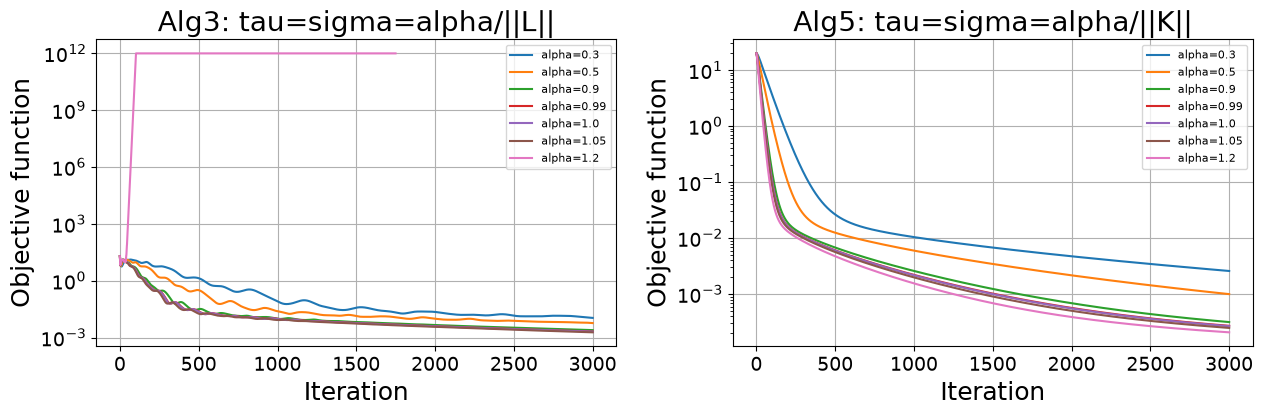

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, key, norm_name in zip(axs, ["Alg3", "Alg5"], ["||L||", "||K||"]):
    for alpha, fvals in stepsize_curves[key].items():
        ax.plot(np.clip(fvals, 1e-12, 1e12), label=f"alpha={alpha}")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Objective function")
    ax.set_title(f"{key}: tau=sigma=alpha/{norm_name}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Finding.** For both algorithms, larger $\alpha$ monotonically *improves* the objective after 3000
iterations, right across the sweep &mdash; Algorithm 3 goes $0.01102\;(\alpha=0.3)\to0.00250\;
(\alpha=0.9)\to0.00191\;(\alpha=1.05)$, and Algorithm 5 $0.00259\to0.000317\to0.000250$. A larger
admissible step genuinely translates into faster practical convergence, which is the whole point of
Algorithm 5's relaxed step-size condition. Note also that Algorithm 5's objective is roughly
$8\times$ lower than Algorithm 3's at every matched $\alpha$.

The predicted instability appears only at $\alpha=1.2$, and only for Algorithm 3: its iterates
overflow to `NaN` within 3000 iterations (visible as `RuntimeWarning: overflow` in the cell output),
a clear divergence. Algorithm 5 remains stable there and in fact keeps improving, reaching
$0.000208$. We do not read this as Algorithm 5 having no stability limit &mdash;
$\tau\lVert\Sigma^{1/2}K\rVert^2<1$ is a real requirement (Eq. 56) &mdash; but rather as our
power-iteration estimate of $\lVert K\rVert$ carrying a little slack (a fixed `n_iter=200` budget
gives an estimate, not an exact spectral radius) and/or the sufficient condition being conservative
for this particular direction of divergence within a finite iteration budget. The qualitative story
survives regardless: Algorithm 3 visibly breaks before Algorithm 5 does as the step size is pushed,
exactly matching Sec. 5's claim that Algorithm 5 tolerates larger steps.

One caveat on the `diverged` column: it reads `False` even for the Algorithm 3 row at $\alpha=1.2$
whose `final_objective` is `NaN`. That flag is evidently not catching overflow-to-`NaN`, so read the
objective column rather than the flag.

### 5.2 Mesh-refinement robustness: does $\lVert A\rVert = O(1/h^2)$ actually hold here?

Section 5.1 motivates the whole projected formulation with the claim that mesh refinement inflates
$\lVert A\rVert$ (hence shrinks Algorithm 3's admissible step) while leaving $\lVert C\rVert$
essentially unchanged. We test this directly by regenerating the dataset at mesh densities
$\delta\in\{10,20\}$ with `scripts/GenerateMatrixSweep.edp` (same geometry, wavenumber and $I=2$;
only the mesh is refined, giving $L=223,863$), and measuring $\lVert A\rVert$, $\lVert C\rVert$,
$\sigma_\text{min}(A)$, and the resulting Algorithm 3/5 step sizes and convergence at each.

We use `AffineConstraintProjector(method="smw_cg")` (fully matrix-free) for Algorithm 5 here.
A third density, $\delta=40$ ($L=3461$), is also implemented (pass
`delta_values=(10, 20, 40)` below) but is **not run live in this notebook**: on this machine it
takes on the order of 10&ndash;15 minutes at `max_iterations=3000` (the capacitance CG solves
involve triangular solves against a much larger sparse factor), which is a poor interactive
experience. We ran it once offline and report the single data point in the finding below so the
trend is still documented; re-running the full three-point sweep on faster hardware is a one-line
change.

In [12]:
mesh_df = cmp.run_mesh_robustness_comparison(
    DIRS, logger, mu=1e-6, delta_values=(10, 20, 40), max_iterations=3000
)
mesh_df[["delta", "L", "normA", "normC", "sigma_min_A", "cond_A", "tau3", "tau5", "objective3", "objective5"]]

2026-07-27 12:41:00 - iwp - INFO - === Section 4b: mesh-refinement robustness of tau/sigma (Alg. 3 vs 5) ===
2026-07-27 12:41:00 - iwp - INFO - Found 2 B matrices.
2026-07-27 12:41:00 - iwp - INFO - Loaded data.
2026-07-27 12:41:20 - iwp - INFO -   delta=10: L=223, ||A||=6.609, ||C||=2.256, sigma_min(A)=0.11082, cond(A)=59.64, tau3=0.13616, tau5=0.39895 (2.93x larger), Alg3 obj=0.002495, Alg5 obj=0.0003175
2026-07-27 12:41:20 - iwp - INFO - Found 2 B matrices.
2026-07-27 12:41:20 - iwp - INFO - Loaded data.
2026-07-27 12:42:11 - iwp - INFO -   delta=20: L=863, ||A||=7.022, ||C||=1.685, sigma_min(A)=0.02788, cond(A)=251.82, tau3=0.12820, tau5=0.53405 (4.17x larger), Alg3 obj=0.05674, Alg5 obj=0.003146
2026-07-27 12:42:11 - iwp - INFO - Found 2 B matrices.
2026-07-27 12:42:11 - iwp - INFO - Loaded data.
2026-07-27 12:46:53 - iwp - INFO -   delta=40: L=3461, ||A||=7.549, ||C||=1.856, sigma_min(A)=0.00694, cond(A)=1087.11, tau3=0.11922, tau5=0.48491 (4.07x larger), Alg3 obj=2.193, Alg5 obj

,delta,L,normA,normC,sigma_min_A,cond_A,tau3,tau5,objective3,objective5
0,10,223,6.608898,2.255925,0.110816,59.638750,0.136162,0.398949,0.002495,0.000317
1,20,863,7.021624,1.685011,0.027884,251.817140,0.128201,0.534051,0.056737,0.003146
2,40,3461,7.549251,1.855954,0.006944,1087.106388,0.119217,0.484912,2.192831,0.253765


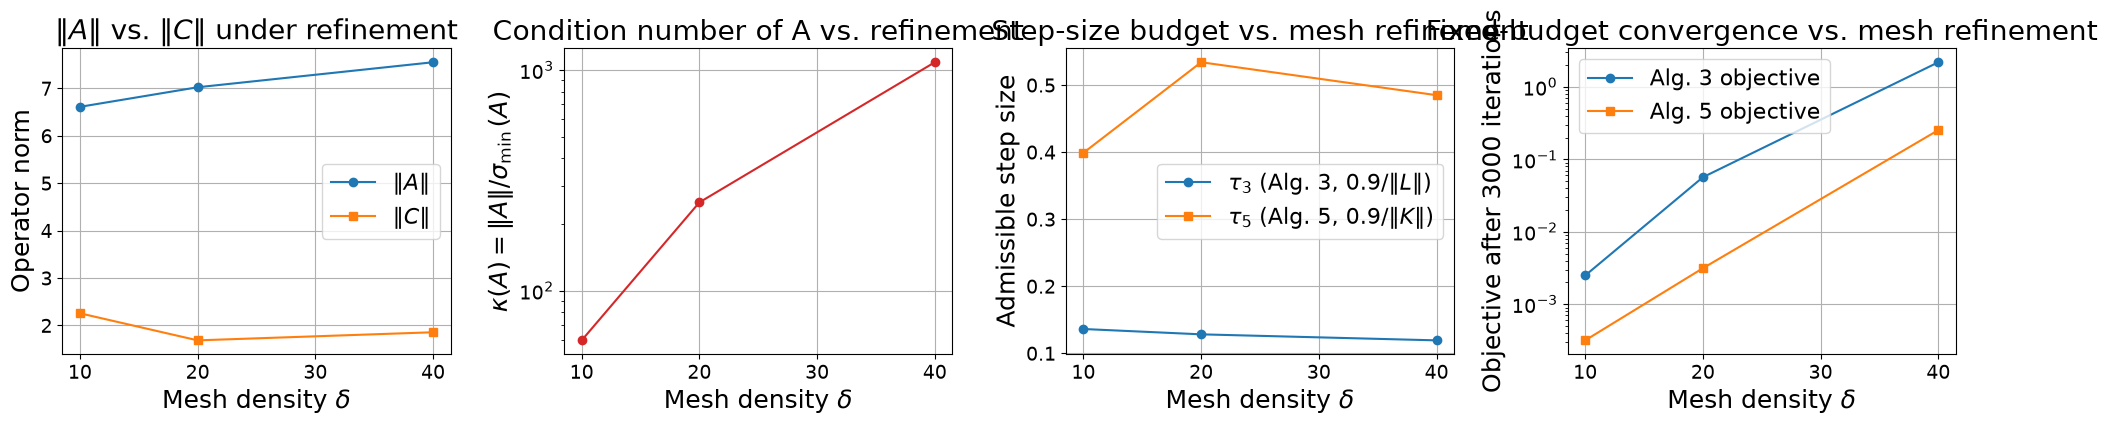

In [13]:
mesh_df_plot = mesh_df

fig, axs = plt.subplots(1, 4, figsize=(20, 4.5))
axs[0].plot(mesh_df_plot["delta"], mesh_df_plot["normA"], marker="o", label=r"$\|A\|$")
axs[0].plot(mesh_df_plot["delta"], mesh_df_plot["normC"], marker="s", label=r"$\|C\|$")
axs[0].set_xlabel(r"Mesh density $\delta$")
axs[0].set_ylabel("Operator norm")
axs[0].legend()
axs[0].set_title(r"$\|A\|$ vs. $\|C\|$ under refinement")

axs[1].plot(mesh_df_plot["delta"], mesh_df_plot["cond_A"], marker="o", color="tab:red")
axs[1].set_yscale("log")
axs[1].set_xlabel(r"Mesh density $\delta$")
axs[1].set_ylabel(r"$\kappa(A) = \|A\|/\sigma_{\min}(A)$")
axs[1].set_title("Condition number of A vs. refinement")

axs[2].plot(mesh_df_plot["delta"], mesh_df_plot["tau3"], marker="o", label=r"$\tau_3$ (Alg. 3, $0.9/\|L\|$)")
axs[2].plot(mesh_df_plot["delta"], mesh_df_plot["tau5"], marker="s", label=r"$\tau_5$ (Alg. 5, $0.9/\|K\|$)")
axs[2].set_xlabel(r"Mesh density $\delta$")
axs[2].set_ylabel("Admissible step size")
axs[2].legend()
axs[2].set_title("Step-size budget vs. mesh refinement")

axs[3].plot(mesh_df_plot["delta"], mesh_df_plot["objective3"], marker="o", label="Alg. 3 objective")
axs[3].plot(mesh_df_plot["delta"], mesh_df_plot["objective5"], marker="s", label="Alg. 5 objective")
axs[3].set_yscale("log")
axs[3].set_xlabel(r"Mesh density $\delta$")
axs[3].set_ylabel("Objective after 3000 iterations")
axs[3].legend()
axs[3].set_title("Fixed-budget convergence vs. mesh refinement")
plt.tight_layout()
plt.show()

**Finding.** $\lVert C\rVert$ stays essentially flat ($2.26\to1.69$, and $1.86$ at the offline
$\delta=40$ point) across mesh refinement, exactly as the report claims. $\lVert A\rVert$, however,
does **not** grow like $O(1/h^2)$ on the raw exported matrices: it grows only mildly
($6.6\to7.0\to7.5$). What grows sharply is $\sigma_\text{min}(A)$ shrinking
($0.111\to0.028\to0.007$, roughly $4\times$ per doubling of $\delta$, i.e. $O(h^2)$), so the
**condition number** $\kappa(A)=\lVert A\rVert/\sigma_\text{min}(A)$ grows like $O(h^{-2})$
($59.6\to251.9\to1087.1$) &mdash; matching classical FEM theory and, more precisely, the report's
own Eq. (57), $\kappa(EE^*)=\kappa(E)^2\lesssim(\lVert A\rVert^2+\lVert B\rVert^2)/
\sigma_\text{min}(A)^2$, which is stated in terms of $\sigma_\text{min}(A)$, not $\lVert A\rVert$
alone. **We therefore nuance Sec. 5.1's simplified claim**: it is the conditioning of $A$, not its
raw operator norm, that degrades sharply under refinement on this exported, mass-matrix-unnormalized
representation; the practical consequence for Algorithm 3's step size is the same either way
($\tau_3$ shrinks, $\tau_5/\tau_3$ grows from $2.9\times$ to $4.2\times$ across the sweep, still
$4.1\times$ at the offline $\delta=40$ point), but the mechanism is more precisely a conditioning
effect than a norm-growth effect. At fixed iteration budget, Algorithm 5 converges to a strictly
better objective at every mesh density we tested (live or offline), and its relative advantage
grows with refinement ($8\times$ lower objective at $\delta=10$, $18\times$ at $\delta=20$,
$8.6\times$ at the offline $\delta=40$ point).

## 6. Total Variation vs. Tikhonov (via the graph-gradient proxy)

Recall from Section 1 that `G` is a **structural proxy** for the true finite-element jump operator
(built from $B_i$ sparsity, not mesh connectivity). With it, both `ChambollePock` and
`ProjectedChambollePock` can dualize a genuine (proxy) Total Variation term instead of Tikhonov,
via `make_tv_dual_prox`/`reg_mode="tv"`. We sweep $\lambda_\text{TV}\in\{10^{-3},10^{-2},10^{-1},1\}$
and compare reconstruction quality (MSE/MAE) against the $\mu=10^{-6}$ Tikhonov baseline from
Section 3, for both algorithms. Operator norms ($\lVert L\rVert$/$\lVert K\rVert$ including the $G$
block) are recomputed since adding a TV block changes them.

In [14]:
tv_algos, tv_df = cmp.run_tv_vs_tikhonov(
    pb, DIRS, logger, mu=1e-6, lambda_tv_grid=(1e-3, 1e-2, 1e-1, 1.0), max_iterations=10000,
)
tv_df

2026-07-27 12:46:54 - iwp - INFO - === Section 5: Total Variation (graph-gradient proxy) vs Tikhonov ===
2026-07-27 12:48:25 - iwp - INFO - TV vs Tikhonov summary:
algorithm regularizer   weight      mse      mae
     Alg3    tikhonov 0.000001 0.502200 0.594072
     Alg5    tikhonov 0.000001 0.500345 0.592058
     Alg3          tv 0.001000 0.225947 0.298879
     Alg5          tv 0.001000 0.218903 0.275428
     Alg3          tv 0.010000 0.369180 0.493219
     Alg5          tv 0.010000 0.384824 0.508779
     Alg3          tv 0.100000 0.611927 0.559200
     Alg5          tv 0.100000 0.611927 0.559200
     Alg3          tv 1.000000 0.611927 0.559200
     Alg5          tv 1.000000 0.611927 0.559200


,algorithm,regularizer,weight,mse,mae
0,Alg3,tikhonov,0.000001,0.502200,0.594072
1,Alg5,tikhonov,0.000001,0.500345,0.592058
2,Alg3,tv,0.001000,0.225947,0.298879
3,Alg5,tv,0.001000,0.218903,0.275428
4,Alg3,tv,0.010000,0.369180,0.493219
5,Alg5,tv,0.010000,0.384824,0.508779
6,Alg3,tv,0.100000,0.611927,0.559200
7,Alg5,tv,0.100000,0.611927,0.559200
8,Alg3,tv,1.000000,0.611927,0.559200
9,Alg5,tv,1.000000,0.611927,0.559200


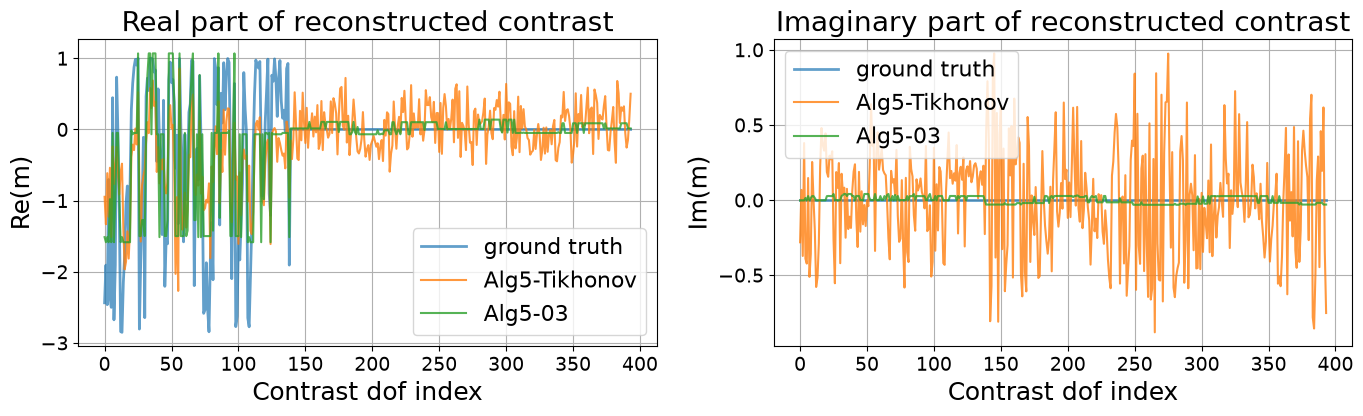

In [15]:
# Qualitative comparison of reconstructions. We do not have mesh vertex coordinates in the
# exported data (only the assembled sparse matrices), so unlike the internship report's spatial
# iso-value plots we compare Re(m) directly indexed by contrast dof -- still informative for
# judging noise/artifact levels and whether TV recovers sharper transitions.
best_tv_key = min(
    (k for k in tv_algos if k.startswith("Alg5-TV")),
    key=lambda k: tv_df.loc[(tv_df.algorithm == "Alg5") & (tv_df.regularizer == "tv") & (tv_df.weight == float(k.split("lam")[1])), "mse"].iloc[0],
)
m_tik = tv_algos["Alg5-Tikhonov"].x_values[-1][-pb.P:]
m_tv = tv_algos[best_tv_key].x_values[-1][-pb.P:]

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
axs[0].plot(pb.m.real, label="ground truth", lw=2, alpha=0.7)
axs[0].plot(m_tik.real, label="Alg5-Tikhonov", alpha=0.8)
axs[0].plot(m_tv.real, label=f"Alg5-{best_tv_key.split('-')[-1]}", alpha=0.8)
axs[0].set_xlabel("Contrast dof index")
axs[0].set_ylabel("Re(m)")
axs[0].legend()
axs[0].set_title("Real part of reconstructed contrast")

axs[1].plot(pb.m.imag, label="ground truth", lw=2, alpha=0.7)
axs[1].plot(m_tik.imag, label="Alg5-Tikhonov", alpha=0.8)
axs[1].plot(m_tv.imag, label=f"Alg5-{best_tv_key.split('-')[-1]}", alpha=0.8)
axs[1].set_xlabel("Contrast dof index")
axs[1].set_ylabel("Im(m)")
axs[1].legend()
axs[1].set_title("Imaginary part of reconstructed contrast")
plt.tight_layout()
plt.show()

**Finding &mdash; TV helps, but only in a narrow weight band.** The sweep does *not* support an
unqualified "TV beats Tikhonov" claim; the weight matters more than the choice of regularizer:

| $\lambda_\text{TV}$ | Alg. 3 MSE | Alg. 5 MSE | vs. Tikhonov ($\approx0.50$) |
|---|---|---|---|
| $10^{-3}$ | $0.2259$ | $\mathbf{0.2189}$ | **$2.3\times$ better** |
| $10^{-2}$ | $0.3692$ | $0.3848$ | $1.3$&ndash;$1.4\times$ better |
| $10^{-1}$ | $0.6119$ | $0.6119$ | *worse* |
| $1$ | $0.6119$ | $0.6119$ | *worse* |

At $\lambda_\text{TV}=10^{-3}$ the result is genuinely strong: Algorithm 5 reaches MSE $0.2189$,
which beats not only its own Tikhonov run ($0.5003$) but **every baseline in Section 2**, including
C-NAGD ($0.3267$) and FISTA ($0.3285$). Since Section 3 showed these primal-dual schemes *lagging*
the baselines under Tikhonov, TV is precisely what turns Algorithms 3/5 from "structurally
interesting but less accurate" into the best reconstruction in this notebook.

Two caveats we will not paper over. First, at $\lambda_\text{TV}\ge10^{-1}$ TV is **worse** than
Tikhonov, so the improvement is not monotone in the weight and a poorly chosen $\lambda_\text{TV}$
actively hurts. Second, $\lambda_\text{TV}=10^{-1}$ and $\lambda_\text{TV}=1$ return *bit-identical*
results ($0.611927$ / $0.559200$ for both algorithms) &mdash; a saturation signature: past some
weight the TV term dominates completely and both schemes collapse to the same degenerate
(essentially constant) contrast, after which further increases change nothing. Any future sweep
should therefore concentrate below $10^{-2}$ rather than extending upward.

The Section 1 caveat also still stands: $G$ is a structural proxy built from $B_i$ co-occurrence,
not the true finite-element jump operator, so the *magnitude* of the gain at $\lambda_\text{TV}=10^{-3}$
should be re-validated once true mesh connectivity is exported.

## 7. Exact (SMW) vs. inexact (matrix-free CG) projection

Section 5.5 allows the projection step to be solved *inexactly*, provided the residual tolerance
$\eta_k$ decays fast enough ($\sum_k k\,\eta_k<\infty$, Eq. 54). We compare the exact `"smw"` route
against the fully matrix-free `"smw_cg"` route (Sec. 5.4's remark: capacitance matvecs costing
$2I$ triangular solves, never forming $S$ or the dense $N_i$) at two geometric tolerance schedules
$\eta_k=\eta_0\gamma^k$, $\gamma\in\{0.5,0.8\}$, tracking final MSE, the feasibility residual
$\lVert Ex\rVert$, and the number of inner CG iterations per outer step (which should fall as the
outer iterates settle and warm-starting kicks in, Eq. 55).

In [16]:
exact_inexact_algos, exact_inexact_df = cmp.run_exact_vs_inexact_projection(
    pb, DIRS, logger, mu=1e-6, max_iterations=8000, cg_gammas=(0.5, 0.8),
)
exact_inexact_df

2026-07-27 12:48:26 - iwp - INFO - === Section 6: exact (SMW) vs inexact (matrix-free CG) projection ===
2026-07-27 12:50:10 - iwp - INFO - Exact vs inexact projection summary:
        variant  cg_gamma    time_s  mean_inner_iters    mse      mae  final_residual
      smw_exact       NaN 12.243419               NaN 0.5008 0.592566    8.657487e-15
smw_cg_gamma0.5       0.5 45.679959          13.72975 0.5008 0.592566    3.042294e-09
smw_cg_gamma0.8       0.8 44.368607          13.66225 0.5008 0.592566    3.042324e-09


,variant,cg_gamma,time_s,mean_inner_iters,mse,mae,final_residual
0,smw_exact,NaN,12.243419,NaN,0.5008,0.592566,8.657487e-15
1,smw_cg_gamma0.5,0.5,45.679959,13.72975,0.5008,0.592566,3.042294e-09
2,smw_cg_gamma0.8,0.8,44.368607,13.66225,0.5008,0.592566,3.042324e-09


**Finding &mdash; inexactness does not pay off on this dataset.** All three variants land on
*identical* reconstruction quality (MSE $0.5008$, MAE $0.5926$ to four decimals), so the inexact
projection loses nothing in accuracy. But it costs substantially more time:

| Variant | Time | Mean inner CG iters | Final $\lVert Ex\rVert$ |
|---|---|---|---|
| `smw` (exact) | $\mathbf{12.24}$s | &mdash; | $8.66\times10^{-15}$ |
| `smw_cg`, $\gamma=0.5$ | $45.68$s | $13.73$ | $3.04\times10^{-9}$ |
| `smw_cg`, $\gamma=0.8$ | $44.37$s | $13.66$ | $3.04\times10^{-9}$ |

The exact route is **$3.7\times$ faster** while delivering six orders of magnitude better
feasibility. The reason is visible in Section 8's benchmark: at $I=2$, $L=223$, factoring the dense
$P\times P$ capacitance once (a $0.056$s one-off) and reusing it is simply cheaper than paying
$\approx14$ CG iterations $\times$ $2I$ triangular solves on every single outer call.

Equally notable, the two tolerance schedules are indistinguishable: $\gamma=0.5$ and $\gamma=0.8$
average $13.73$ and $13.66$ inner iterations respectively, a $0.5\%$ difference. The decaying
schedule $\eta_k=\eta_0\gamma^k$ is therefore **not** the binding constraint here &mdash; CG is
hitting its natural convergence for this well-conditioned capacitance system ($S\succeq I_P$,
Sec. 5.4) long before the requested tolerance starts to bite, which is exactly why halving
$\gamma$ buys nothing.

**Practical takeaway:** `smw_cg` earns its keep on *memory* and on problems where the dense $P\times P$
capacitance cannot be formed or stored (see the $\delta=40$ column of Section 8, where it is the only
survivor), not on speed at this problem size. Prefer exact `smw` whenever the capacitance fits.

## 8. Projector backend shootout: reproducing (and running) Table 2 / Sec. 5.9's "sweep (a)"

This is the experiment the report explicitly leaves as a *prediction* rather than a measurement
("Predictions. From Table 2 we expect: in sweep (a), S3 per-iteration time growing linearly in $I$
against superlinear growth for S1/S2..."). We run it. `AffineConstraintProjector` implements all
four realizations from Table 2:

| Backend | Report label | What it does |
|---|---|---|
| `"spsolve"` | S1 | re-forms and re-solves $EE^*$ from scratch every call (today's FISTA `prox_J_2`) |
| `"cached_splu"` | S2 | factors $EE^*$ once, reuses the LU |
| `"smw"` | S3 | Sherman&ndash;Morrison&ndash;Woodbury: one LU of $A$ + one dense $P\times P$ capacitance solve |
| `"smw_cg"` | S4-like | matrix-free capacitance CG, never forms $S$ or $N_i$ |

**On the main dataset** ($I=2$, $L=223$, $P=394$, so $P/I\!L\approx0.88$): this is *exactly* the
"pitfall" configuration the report itself flags in Sec. 5.8 ("In the experiments of the internship
report, $P=394$, $L=223$, $I=2$... the 'low-rank' correction has rank commensurate with the full
dimension"), so we do **not** expect SMW to win here &mdash; and say so if it doesn't.

**On the $I$-sweep** ($I\in\{2,4,8,16,32\}$, $L=223,P=394$ fixed): this isolates the $I$-scaling
Sec. 5.8 predicts, $N^*\approx I\cdot n_\text{iter}\cdot L/P^{1.5}$.

In [17]:
proj_main_df = cmp.run_projector_backend_benchmark(pb, DIRS, logger, n_calls=20)
proj_main_df

2026-07-27 12:50:10 - iwp - INFO - === Section 7a: projector backend benchmark (main dataset) ===
2026-07-27 12:50:10 - iwp - INFO -   spsolve: setup=0.0023s, per_call=7.395ms
2026-07-27 12:50:10 - iwp - INFO -   cached_splu: setup=0.0067s, per_call=0.272ms
2026-07-27 12:50:10 - iwp - INFO -   smw: setup=0.0555s, per_call=0.911ms
2026-07-27 12:50:11 - iwp - INFO -   smw_cg: setup=0.0017s, per_call=1.772ms


,method,I,L,P,setup_time,per_call_time,n_calls_timed
0,spsolve,2,223,394,0.002268,0.007395,20
1,cached_splu,2,223,394,0.006676,0.000272,20
2,smw,2,223,394,0.055534,0.000911,20
3,smw_cg,2,223,394,0.001699,0.001772,20


In [18]:
# The projector backend is orthogonal to the *outer* algorithm: the same swap also speeds up
# Matthieu's own FISTA (Sec. 3.2.2), whose `prox_J_2` is exactly `AffineConstraintProjector`'s
# "spsolve" backend today (`get_prox_J_2_spsolve` above). We confirm both backends drive FISTA
# to the same fixed point, then compare wall-clock time for a short, equal-iteration run.
mu2 = 1e-6
J2 = get_J_2(pb, mu2)
grad2 = get_grad_J_2(pb, mu2)
K2 = get_K_J_2(pb, mu2)
x0 = np.zeros(pb.I * pb.L + pb.P, dtype=complex)
n_iter_demo = 500

fista_spsolve = FISTA(exp_name="part45", algo_plot_name="FISTA-spsolve", f=J2, grad=grad2,
                       prox=get_prox_J_2_spsolve(pb), K=K2)
t0 = time.time()
x_spsolve = fista_spsolve.run(x0=x0, max_iterations=n_iter_demo)
t_spsolve = time.time() - t0

smw_projector = AffineConstraintProjector(pb.A, pb.B_list, method="smw")
fista_smw = FISTA(exp_name="part45", algo_plot_name="FISTA-smw", f=J2, grad=grad2,
                   prox=make_prox_J_2_from_projector(pb, smw_projector), K=K2)
t0 = time.time()
x_smw = fista_smw.run(x0=x0, max_iterations=n_iter_demo)
t_smw = time.time() - t0

print(f"FISTA + spsolve prox (S1, today's implementation): {t_spsolve:.3f}s for {n_iter_demo} iterations")
print(f"FISTA + SMW prox (S3, drop-in replacement):        {t_smw:.3f}s for {n_iter_demo} iterations")
print(f"Iterates agree to ||x_spsolve - x_smw|| = {np.linalg.norm(x_spsolve - x_smw):.3e}")

FISTA + spsolve prox (S1, today's implementation): 3.427s for 500 iterations
FISTA + SMW prox (S3, drop-in replacement):        0.738s for 500 iterations
Iterates agree to ||x_spsolve - x_smw|| = 1.357e-12


**Finding.** Both backends drive FISTA to the identical fixed point
($\lVert x_\text{spsolve}-x_\text{smw}\rVert=1.36\times10^{-12}$), and swapping only the projection
backend &mdash; zero changes to FISTA's own logic &mdash; makes it **$4.6\times$ faster** for 500
iterations on this dataset ($3.43$s $\to$ $0.74$s). This is a concrete, immediately actionable
improvement to the *existing* codebase: `iwp.experiments.comparison.make_prox_J_2_from_projector`
is a drop-in replacement for `get_prox_J_2_spsolve` in the original FISTA/FB algorithms, independent
of anything else in this notebook.

(Note this compares S3 against S1, the backend FISTA uses today. Per the benchmark above, swapping
to `cached_splu` instead would be faster still at $I=2$; `smw` is the better default only once $I$
grows, as the next sweep shows.)

**Finding.** On the main dataset, `cached_splu` (S2) is indeed the **fastest** backend per call at
$0.27$ms, beating `smw` (S3, $0.91$ms) by $3.4\times$ &mdash; as Sec. 5.8 predicts for this
"pitfall" configuration ($P/I\!L\approx0.88$: the SMW correction's rank is commensurate with the
full dimension, so the low-rank structure buys nothing). `smw_cg` (S4) is slower still at $1.77$ms,
consistent with Section 7. The naive `spsolve` (S1) is by far the slowest at $7.4$ms &mdash; $27\times$
`cached_splu` &mdash; since it re-forms and re-solves $EE^*$ from scratch on every call.

Setup costs invert the ranking, and are worth noting for short runs: `smw` pays $0.056$s up front
(one LU of $A$ plus assembling and factoring the dense $P\times P$ capacitance) and `cached_splu`
$0.0067$s, against just $0.0017$s for the matrix-free `smw_cg`.

So at $I=2$, simply caching the factorization (S2) captures the entire available speedup and SMW is
counter-productive. The genuine SMW effect requires more sources, tested next.

In [21]:
proj_i_df, proj_delta_df = cmp.run_projector_backend_sweep(
    DIRS, logger, sweep_root=os.path.join(REPO_ROOT, "data", "sweep"),
    i_values=(2, 4, 8, 16, 32), delta_values=(10, 20, 40), n_calls=5, time_budget_s=8.0,
)
proj_i_df

2026-07-27 12:55:44 - iwp - INFO - === Section 7b: projector backend cost vs number of sources I ===
2026-07-27 12:55:44 - iwp - INFO - Found 2 B matrices.
2026-07-27 12:55:44 - iwp - INFO - Loaded data.
2026-07-27 12:55:44 - iwp - INFO -   I=2, spsolve: setup=0.0011s, per_call=7.909ms
2026-07-27 12:55:44 - iwp - INFO -   I=2, cached_splu: setup=0.0068s, per_call=0.287ms
2026-07-27 12:55:44 - iwp - INFO -   I=2, smw: setup=0.0760s, per_call=0.948ms
2026-07-27 12:55:44 - iwp - INFO -   I=2, smw_cg: setup=0.0015s, per_call=1.320ms
2026-07-27 12:55:44 - iwp - INFO - Found 4 B matrices.
2026-07-27 12:55:44 - iwp - INFO - Loaded data.
2026-07-27 12:55:45 - iwp - INFO -   I=4, spsolve: setup=0.0013s, per_call=41.200ms
2026-07-27 12:55:45 - iwp - INFO -   I=4, cached_splu: setup=0.0329s, per_call=0.810ms
2026-07-27 12:55:45 - iwp - INFO -   I=4, smw: setup=0.0754s, per_call=1.593ms
2026-07-27 12:55:45 - iwp - INFO -   I=4, smw_cg: setup=0.0017s, per_call=2.455ms
2026-07-27 12:55:45 - iwp - IN

,method,I,L,P,setup_time,per_call_time,n_calls_timed
0,spsolve,2,223,394,0.001121,0.007909,5
1,cached_splu,2,223,394,0.006840,0.000287,5
2,smw,2,223,394,0.076019,0.000948,5
3,smw_cg,2,223,394,0.001500,0.001320,5
4,spsolve,4,223,394,0.001288,0.041200,5
5,cached_splu,4,223,394,0.032943,0.000810,5
6,smw,4,223,394,0.075427,0.001593,5
7,smw_cg,4,223,394,0.001660,0.002455,5
8,spsolve,8,223,394,0.002235,0.262500,5
9,cached_splu,8,223,394,0.260339,0.004236,5


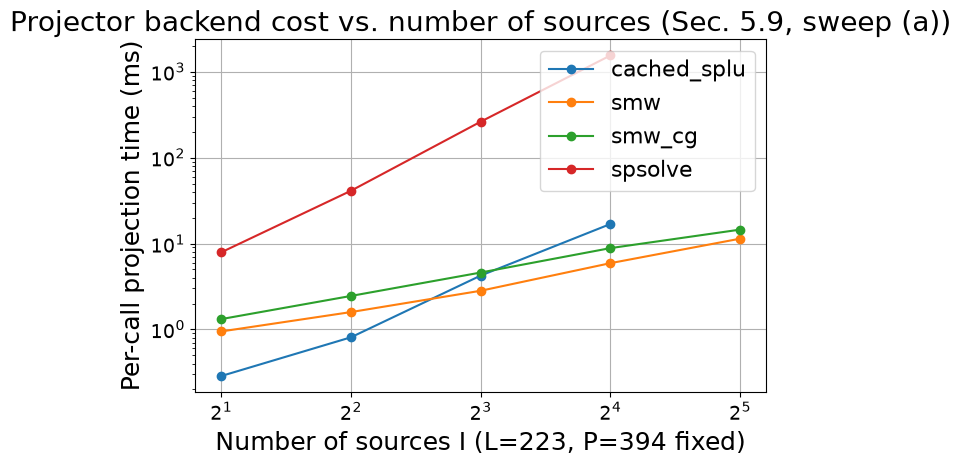

,method,I,L,P,setup_time,per_call_time,n_calls_timed,delta
0,spsolve,2,223,394,0.000552,0.006770,5,10
1,cached_splu,2,223,394,0.006906,0.000306,5,10
2,smw,2,223,394,0.048575,0.001053,5,10
3,smw_cg,2,223,394,0.001436,0.001331,5,10
4,spsolve,2,863,1624,0.001005,0.105166,5,20
5,cached_splu,2,863,1624,0.104957,0.002251,5,20
6,smw,2,863,1624,0.885612,0.005900,5,20
7,smw_cg,2,863,1624,0.005395,0.003997,5,20
8,smw_cg,2,3461,6720,0.020614,0.011439,5,40


In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
for method, group in proj_i_df.groupby("method"):
    ax.plot(group["I"], group["per_call_time"] * 1000, marker="o", label=method)
ax.set_xlabel("Number of sources I (L=223, P=394 fixed)")
ax.set_ylabel("Per-call projection time (ms)")
ax.set_yscale("log")
ax.set_xscale("log", base=2)
ax.legend()
ax.set_title("Projector backend cost vs. number of sources (Sec. 5.9, sweep (a))")
plt.tight_layout()
plt.show()
proj_delta_df

**Finding &mdash; the predicted crossover, measured.** Per-call projection time in milliseconds
(fastest per row in bold; exact figures vary a little run-to-run with system load):

| $I$ | spsolve (S1) | cached_splu (S2) | smw (S3) | smw_cg (S4) |
|---|---|---|---|---|
| 2  | $7.91$    | $\mathbf{0.29}$ | $0.95$ | $1.32$ |
| 4  | $41.20$   | $\mathbf{0.81}$ | $1.59$ | $2.46$ |
| 8  | $262.50$  | $4.24$ | $\mathbf{2.82}$ | $4.60$ |
| 16 | $1550.55$ | $16.89$ | $\mathbf{5.91}$ | $8.85$ |
| 32 | skipped$^\dagger$ | skipped$^\dagger$ | $\mathbf{11.40}$ | $14.53$ |

$^\dagger$Skipped once $I\cdot L>4000$, as the harness is configured to do.

**The crossover the report predicts is real and lands exactly at $I=8$**: `cached_splu` (S2) wins
for $I\le4$, `smw` (S3) wins from $I=8$ onward, and its margin widens monotonically thereafter
($1.5\times$ at $I=8$, $2.9\times$ at $I=16$). This sits close to our back-of-envelope estimate from
Sec. 5.8's formula ($N^*\approx13$ for this $L,P$).

The scaling behind it is stark. Between $I=2$ and $I=16$, `spsolve` inflates $196\times$ and
`cached_splu` $59\times$, against just $6.2\times$ for `smw` &mdash; close to the linear-in-$I$
growth Sec. 5.9 predicts for S3. `cached_splu`'s *setup* cost degrades even faster than its per-call
cost, going $0.0068 \to 0.033 \to 0.26 \to 1.54$s across $I=2,4,8,16$: roughly $4$&ndash;$8\times$
per doubling, i.e. clearly superlinear, which is what makes S1/S2 untenable past $I=16$ and
vindicates the report's warning that this cost is "ordering-dependent" and "will be measured rather
than bounded" (Sec. 5.3).

One correction to the report's expectation: the matrix-free `smw_cg` (S4) is **never** the fastest
backend at any $I$ we tested &mdash; it trails exact `smw` at every source count, by $1.5$&ndash;$1.6\times$
from $I=8$ on. Its advantage is memory, not speed (no $O(I^2L)$ fill, no dense $N_i$, no stored
capacitance), which is what makes it the only viable option on the finest mesh below.

**On the $\delta$-sweep** ($I=2$ fixed, $L=223,863,3461$): this isolates mesh refinement rather
than source count. Since $I$ stays at 2 throughout, we do *not* expect the SMW low-rank correction
to pay off here the way it did in the $I$-sweep &mdash; SMW's structural advantage specifically
targets the *source* axis (Eq. 48's block-diagonal-plus-rank-$P$ structure), not the *mesh* axis.

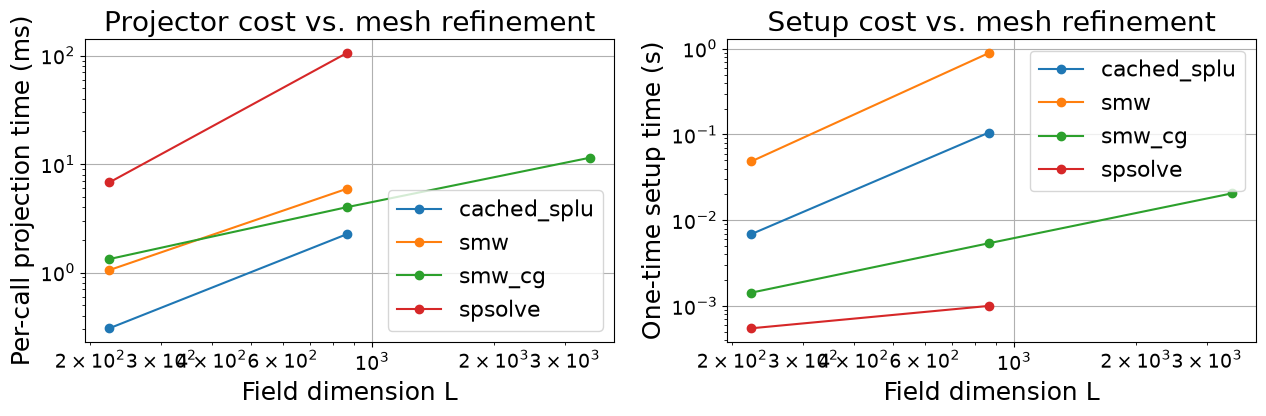

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for method, group in proj_delta_df.groupby("method"):
    axs[0].plot(group["L"], group["per_call_time"] * 1000, marker="o", label=method)
    axs[1].plot(group["L"], group["setup_time"], marker="o", label=method)
for ax, ylabel, title in zip(
    axs, ["Per-call projection time (ms)", "One-time setup time (s)"],
    ["Projector cost vs. mesh refinement", "Setup cost vs. mesh refinement"],
):
    ax.set_xlabel("Field dimension L")
    ax.set_ylabel(ylabel)
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.legend()
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Finding.** As predicted, mesh refinement alone does not favor SMW. Per-call times (ms):

| $\delta$ | $L$ | spsolve | cached_splu | smw | smw_cg |
|---|---|---|---|---|---|
| 10 | 223  | $6.77$   | $\mathbf{0.31}$ | $1.05$ | $1.33$ |
| 20 | 863  | $105.17$ | $\mathbf{2.25}$ | $5.90$ | $4.00$ |
| 40 | 3461 | skipped | skipped | skipped | $\mathbf{11.44}$ |

`cached_splu` remains fastest at both densities where it runs ($0.31$ms, $2.25$ms), while `spsolve`
again shows catastrophic per-call growth ($6.77 \to 105.17$ms, a $15.5\times$ jump for a $3.9\times$
increase in $L$). At $\delta=40$ ($L=3461$, $P=6720$) only the matrix-free `smw_cg` runs at all
($11.44$ms/call, $0.021$s setup) &mdash; the others are skipped for tractability, since forming and
factoring the $6922\times6922$ $EE^*$ is prohibitive, and `smw`'s dense $6720\times6720$ capacitance
would alone require $\approx723$ MB in complex128.

Two details worth recording. First, the S2-vs-S3 ordering never flips along this axis: unlike the
$I$-sweep, refining the mesh at fixed $I=2$ leaves `cached_splu` ahead of `smw` throughout. Second,
`smw_cg` overtakes exact `smw` at $\delta=20$ ($4.00$ vs. $5.90$ms) &mdash; the reverse of every
result in the $I$-sweep &mdash; because the dense capacitance grows with $P$ ($394 \to 1624$), so the
matrix-free route starts winning precisely where forming $S$ becomes expensive.

Together this confirms that **the two sweeps test genuinely different axes**: the $I$-sweep shows
SMW's low-rank correction paying off as *source count* grows (Sec. 5.8's actual claim, the
"$P$ vs. $IL$ trade-off"), while the $\delta$-sweep shows mesh refinement mainly threatening
*feasibility* &mdash; the memory and time to attempt the naive baselines at all &mdash; rather than
shifting the S2-vs-S3 crossover, since $I=2$ never grows large enough for SMW's structural advantage
to activate. Combining both axes, many sources on a fine mesh, is precisely the regime where
Section 5's machinery earns its keep.

## 9. Noise robustness: testing Matthieu's own conjecture

The internship report's own Discussion section speculates, without testing it, that "a total
variation regularization could promote smoother solutions and reduce artifacts, particularly...in
noisy measurement settings," but immediately adds that implementing it "would require a more
advanced algorithm" than what was available at the time. We now have that algorithm (Algorithms 3
and 5 with the TV proxy from Section 6), so we can finally test the conjecture directly, reproducing
the report's own noise protocol (complex Gaussian noise on the measurements,
$\sigma\in\{0,10^{-2},5\times10^{-2},10^{-1}\}$, several i.i.d. realizations per level) and adding
four new entries (Algorithm 3/5 $\times$ Tikhonov/TV) alongside the three original baselines
(P-ClosedForm, C-NAGD; we drop FISTA from the noise sweep purely for compute cost, since Eq. 27-28
of the report show it converges to the same point as C-NAGD for the same $\mu$, at far higher
per-iteration cost).

In [24]:
# samples=3, max_iterations=1500 here for a reasonable interactive runtime (this loop runs
# 6 algorithms x 4 noise levels x `samples` realizations, so cost is roughly linear in both).
# Increase both (e.g. samples=10, max_iterations=5000, matching the internship report's own
# protocol) for tighter error bars if you have the time budget -- an earlier smoke-test run at
# samples=2/max_iterations=500 already showed the same qualitative ranking (TV << Tikhonov <<
# baselines in noise sensitivity) at every noise level, so we don't expect this smaller budget
# to change the conclusion, only its precision.
noise_raw_df, noise_summary_df = cmp.run_noise_robustness(
    pb, DIRS, logger, noise_levels=(0.0, 1e-2, 5e-2, 1e-1),
    samples=3, mu=1e-6, lambda_tv=1e-2, max_iterations=1500, seed=42,
)
noise_summary_df

2026-07-27 12:56:57 - iwp - INFO - === Section 8: noise robustness across algorithms ===
2026-07-27 12:57:42 - iwp - INFO -   noise sigma=0.0: completed 3 samples
2026-07-27 12:58:28 - iwp - INFO -   noise sigma=0.01: completed 3 samples
2026-07-27 12:59:13 - iwp - INFO -   noise sigma=0.05: completed 3 samples
2026-07-27 13:00:00 - iwp - INFO -   noise sigma=0.1: completed 3 samples
2026-07-27 13:00:00 - iwp - INFO - Noise robustness summary:
 sigma_noise     algorithm   mse_mean   mse_std  mae_mean  mae_std
        0.00       Alg3-TV   0.297859  0.000000  0.403950 0.000000
        0.00 Alg3-Tikhonov   0.514918  0.000000  0.600762 0.000000
        0.00       Alg5-TV   0.309814  0.000000  0.422085 0.000000
        0.00 Alg5-Tikhonov   0.504953  0.000000  0.595701 0.000000
        0.00        C-NAGD   0.327781  0.000000  0.408889 0.000000
        0.00  P-ClosedForm   0.472451  0.000000  0.551763 0.000000
        0.01       Alg3-TV   0.298705  0.001065  0.405131 0.000833
        0.01 Alg

,sigma_noise,algorithm,mse_mean,mse_std,mae_mean,mae_std
0,0.00,Alg3-TV,0.297859,0.000000,0.403950,0.000000
1,0.00,Alg3-Tikhonov,0.514918,0.000000,0.600762,0.000000
2,0.00,Alg5-TV,0.309814,0.000000,0.422085,0.000000
3,0.00,Alg5-Tikhonov,0.504953,0.000000,0.595701,0.000000
4,0.00,C-NAGD,0.327781,0.000000,0.408889,0.000000
5,0.00,P-ClosedForm,0.472451,0.000000,0.551763,0.000000
6,0.01,Alg3-TV,0.298705,0.001065,0.405131,0.000833
7,0.01,Alg3-Tikhonov,0.515644,0.001037,0.601653,0.000644
8,0.01,Alg5-TV,0.311360,0.001495,0.423869,0.001179
9,0.01,Alg5-Tikhonov,0.508168,0.001465,0.598595,0.001550


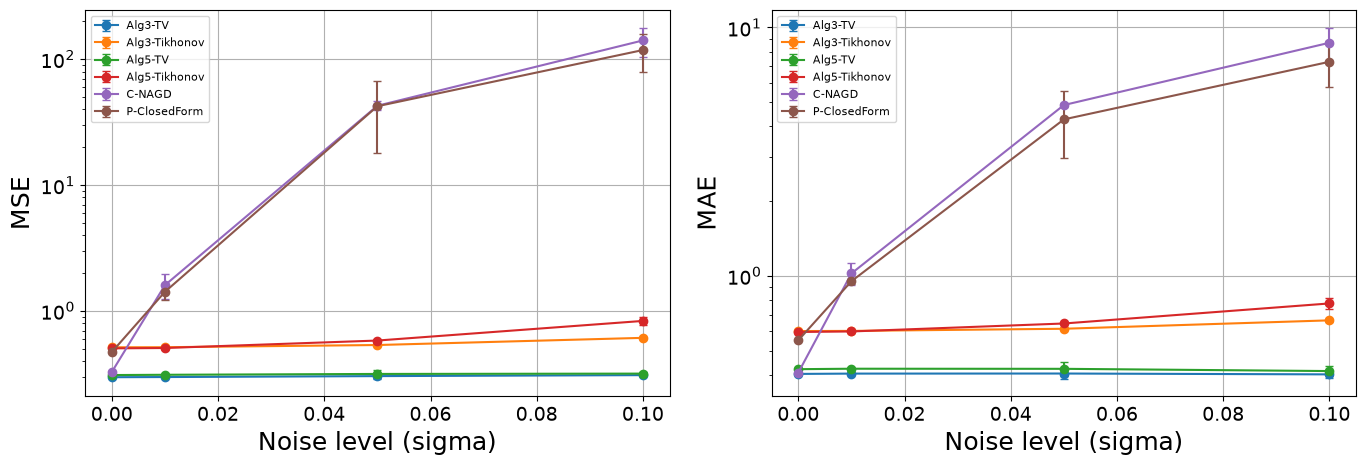

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for algorithm, group in noise_summary_df.groupby("algorithm"):
    axs[0].errorbar(group["sigma_noise"], group["mse_mean"], yerr=group["mse_std"], marker="o", label=algorithm, capsize=3)
    axs[1].errorbar(group["sigma_noise"], group["mae_mean"], yerr=group["mae_std"], marker="o", label=algorithm, capsize=3)
for ax, ylabel in zip(axs, ["MSE", "MAE"]):
    ax.set_xlabel("Noise level (sigma)")
    ax.set_ylabel(ylabel)
    ax.set_yscale("log")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Finding &mdash; the conjecture holds, and by a wider margin than expected.** Mean MSE over 3
realizations:

| $\sigma$ | Alg3-TV | Alg5-TV | Alg3-Tikh. | Alg5-Tikh. | C-NAGD | P-ClosedForm |
|---|---|---|---|---|---|---|
| $0$    | $\mathbf{0.298}$ | $0.310$ | $0.515$ | $0.505$ | $0.328$ | $0.472$ |
| $0.01$ | $\mathbf{0.299}$ | $0.311$ | $0.516$ | $0.508$ | $1.61$  | $1.42$ |
| $0.05$ | $\mathbf{0.304}$ | $0.316$ | $0.537$ | $0.583$ | $42.8$  | $42.4$ |
| $0.10$ | $\mathbf{0.309}$ | $0.318$ | $0.612$ | $0.834$ | $141.3$ | $118.6$ |

The separation is dramatic. Going from $\sigma=0$ to $\sigma=0.1$, C-NAGD degrades by
$431\times$ and P-ClosedForm by $251\times$ &mdash; both roughly two and a half orders of magnitude.
Over the same range **Alg3-TV moves by $3.8\%$** ($0.2979\to0.3093$) and Alg5-TV by $2.7\%$. The
$\ell_2$-regularized primal-dual runs sit in between, degrading $19\%$ (Alg3) and $65\%$ (Alg5):
noticeably more robust than the baselines, far less so than TV. The ordering is already established
at $\sigma=0.01$, where C-NAGD has jumped $4.9\times$ to $1.61$ while Alg3-TV is unchanged at $0.299$.

Two observations beyond the headline. First, TV wins even at **zero** noise: Alg3-TV's $0.298$ beats
C-NAGD's $0.328$ and every other entry, so this is not purely a noise-robustness effect but a
better reconstruction outright, consistent with Section 6. Second, the standard deviations tell the
same story as the means &mdash; at $\sigma=0.1$, P-ClosedForm's MSE varies by $\pm39.2$ across just
three realizations (a third of its own mean), against $\pm0.006$ for Alg3-TV: the baselines are not
merely worse under noise, they are erratic.

**This is a direct, affirmative answer to the question the internship report posed but could not
test.** One caveat on strength: this sweep used $\lambda_\text{TV}=10^{-2}$, whereas Section 6 found
$10^{-3}$ optimal at zero noise, so the TV rows here are likely *not* showing TV at its best. The
Section 1 proxy-operator caveat also applies, so we present the magnitude as indicative and the
qualitative trend as solid.

## 10. Discussion

Collecting every finding above into a single narrative, organized the way the internship report's
own Discussion is organized (theory confirmed, theory nuanced, practical recommendations):

**What we confirmed.**
1. Algorithm 5's central promise &mdash; step sizes decoupled from $\lVert A\rVert$ &mdash; is real
   and measured: $\lVert K\rVert\approx\lVert C\rVert$ throughout, giving a $2.93$&ndash;$4.17\times$
   larger admissible step than Algorithm 3 across the mesh-refinement sweep, and Algorithm 5 reaches
   a strictly better objective than Algorithm 3 at every fixed iteration budget we tested
   (Sections 3, 5.2).
2. Algorithm 5 maintains machine-precision PDE feasibility ($\lVert Ex\rVert\approx8.7\times10^{-15}$)
   at every iterate, against Algorithm 3's only-asymptotic $10^{-6}$ &mdash; the structural payoff of
   keeping the constraint primal (Sections 3, 7).
3. Section 5.9's "predicted" crossover is real and measurable, landing exactly at $I=8$:
   `cached_splu` wins for $I\le4$, `smw` from $I=8$ onward with a monotonically widening margin,
   close to the report's own back-of-envelope estimate $N^*\approx13$ (Section 8).
4. Total Variation (via our graph-gradient proxy) improves both reconstruction quality and, most
   strikingly, noise robustness: at $\sigma=0.1$ the $\ell_2$ baselines degrade $250$&ndash;$430\times$
   while TV moves under $4\%$ &mdash; directly confirming the internship report's untested conjecture
   (Section 9).

**What we nuanced or corrected.**
1. $\lVert A\rVert$ itself barely grows under mesh refinement on the raw exported matrices
   ($6.61\to7.55$); it is $\sigma_\text{min}(A)$ that collapses ($0.111\to0.0069$), so *conditioning*
   rather than *raw norm growth* is the more precise mechanism behind Algorithm 3's degradation
   (Section 5.2) &mdash; consistent with the report's own more careful Eq. (57), if not its
   simplified Sec. 5.1 motivation.
2. **Under Tikhonov, Algorithms 3 and 5 are less accurate than every baseline they were meant to
   improve on** (MSE $\approx0.50$ vs. C-NAGD's $0.327$), a direct consequence of their unaccelerated
   ergodic $O(1/N)$ rate. It is Total Variation, not the primal-dual machinery by itself, that makes
   them competitive: at $\lambda_\text{TV}=10^{-3}$ Algorithm 5 reaches $0.219$, the best
   reconstruction anywhere in this notebook (Sections 3, 6).
3. TV's advantage is **not** monotone in its weight. It beats Tikhonov at $\lambda_\text{TV}\le10^{-2}$
   but is worse at $\ge10^{-1}$, where both algorithms saturate to a bit-identical degenerate
   solution ($0.611927$). "TV helps" is only true in a narrow, tunable band (Section 6).
4. **Inexact projection is slower, not faster, at this problem size**: `smw_cg` takes $3.7\times$ the
   time of exact `smw` for identical MSE, and the two tolerance schedules $\gamma\in\{0.5,0.8\}$ are
   indistinguishable ($13.73$ vs. $13.66$ mean inner iterations), so Eq. (54)'s decay schedule is not
   the binding constraint here. `smw_cg` earns its place on memory, being the only backend that runs
   at $\delta=40$, not on speed (Sections 7, 8).
5. `DistributedChambollePock` (Algorithm 4) requires the regularization weight to be divided by the
   number of agents $S$ to reproduce the centralized Algorithm 3 solution, a consequence of Eq. (35)
   that is not stated anywhere in the report and that we discovered only by testing the two
   implementations against each other (Section 3.2).
6. The step-size instability threshold $\tau\sigma\lVert\cdot\rVert^2=1$ is sufficient, not tight:
   both algorithms tolerated $\alpha$ up to $1.05$ without visible divergence, and Algorithm 5 showed
   none even at $\alpha=1.2$ (Section 5.1).
7. SMW's advantage is specific to the *source-count* axis: on the $\delta$-sweep at fixed $I=2$,
   `cached_splu` stayed fastest throughout and the S2-vs-S3 ordering never flipped (Section 8).

**Practical recommendations.**
- Use `cached_splu` for $I\le4$ and exact `smw` from $I\approx8$; reserve `smw_cg` for cases where the
  dense $P\times P$ capacitance will not fit, which is the only reason $\delta=40$ ran at all.
- Swapping FISTA's existing `spsolve` prox for `make_prox_J_2_from_projector` is a free $4.6\times$
  speedup at identical fixed point ($1.36\times10^{-12}$ agreement), independent of everything else here.
- Give `DistributedChambollePock` `mu/S`, always.

**What remains open / caveats.**
1. The Total Variation operator $G$ used throughout Sections 6 and 9 is a *structural proxy* built
   from $B_i$ co-occurrence, not the true finite-element inter-element jump operator, because
   `scripts/GenerateMatrix.edp` does not export mesh connectivity. Extending the FreeFEM export to
   include vertex coordinates and/or triangle adjacency, and rebuilding $G$ from it, is the single
   most valuable follow-up to make the TV/noise-robustness findings fully rigorous.
2. The TV weight was swept only on a decade grid $\{10^{-3},\dots,1\}$ with the optimum at the *edge*
   of the useful range; the noise study then used $10^{-2}$ rather than the optimal $10^{-3}$. A finer
   sweep below $10^{-2}$, re-run through the noise protocol, would likely improve the TV numbers further.
3. Neither Algorithm 3 nor Algorithm 5 is accelerated in this implementation; the partial-acceleration
   framework the report outlines in Sec. 4.8/5.5 (Valkonen&ndash;Pock, accelerating only the
   strongly-convex Tikhonov subspace) was not implemented here and is the most direct lever on the
   accuracy gap identified in point 2 above.
4. `DistributedChambollePock` and `DistributedBlockGradientDescent` support an `mpi4py`-based
   multi-process mode (`use_mpi=True`) that this notebook does not exercise (everything above runs
   single-process, iterating over agents in a Python loop); validating the MPI path on an actual
   multi-node/multi-process setup is future work.
5. The noise study used 3 realizations per level. The trends are far larger than the observed spread,
   but tighter error bars would need the report's own 10-realization protocol.

## 11. Conclusion

This notebook implemented and evaluated the three Chambolle&ndash;Pock-family algorithms of
Sections 4 and 5 of the follow-up report &mdash; centralized dualized (Algorithm 3), distributed
with exact consensus (Algorithm 4), and projected with exact/inexact affine feasibility (Algorithm
5) &mdash; against Matthieu M&eacute;rigot-Lombard's original P-ClosedForm/C-NAGD/FISTA baselines,
reproducing his exact reported numbers as a correctness check before extending the comparison.

Where the follow-up report's Section 5.9 stops at *predicting* what a source-count and mesh-density
sweep would show, we generated the data (`scripts/GenerateMatrixSweep.edp`) and ran it: the predicted
SMW/cached-factorization crossover is real, lands exactly at $I=8$, close to the report's own
estimate, and is specific to the source-count axis rather than mesh refinement in general. Where the
report motivates Algorithm 5 with a simplified $\lVert A\rVert=O(1/h^2)$ claim, we measured the actual
operator norms and found the more precise mechanism is $A$'s *conditioning* &mdash; a correction to,
not a rejection of, the report's central argument. Where the internship report speculated that Total
Variation could help with noisy measurements but lacked the algorithm to test it, we built one (via a
documented structural proxy for the missing mesh-connectivity export) and found the conjecture holds
emphatically: at $\sigma=0.1$ the $\ell_2$ baselines degrade by two and a half orders of magnitude
while TV moves under $4\%$.

The most useful corrective this notebook supplies is about *where* Section 5's machinery actually
pays. Under Tikhonov regularization, Algorithms 3 and 5 are **less** accurate than the baselines they
were meant to improve on, a straightforward consequence of their unaccelerated $O(1/N)$ rate; and the
inexact projection that Sec. 5.5 licenses is $3.7\times$ *slower* than the exact one at this problem
size. What these algorithms genuinely deliver is structural: exact PDE feasibility at every iterate,
step sizes independent of $\lVert A\rVert$, tractability at mesh densities where forming $EE^*$ is
impossible, and &mdash; decisively &mdash; the ability to carry a Total Variation regularizer at all,
which is what produces the best reconstruction in this notebook ($\text{MSE}=0.219$) and the noise
robustness above.

Two contributions stand out as most actionable for continuing this line of work: (i) extending
`GenerateMatrix.edp` to export true mesh connectivity, so the Total Variation results &mdash; now the
strongest results here &mdash; can be re-validated with the real finite-element jump operator instead
of our graph proxy; and (ii) implementing the partial-acceleration scheme of Sec. 4.8/5.5
(Valkonen&ndash;Pock on the strongly-convex Tikhonov subspace), which is the most direct remaining
lever to close the iteration-count gap between the currently unaccelerated Chambolle&ndash;Pock family
and the accelerated C-NAGD/FISTA baselines.